# Parkinson's Disease Classification Using Smartwatch Data

## Abstract
This notebook presents a machine learning approach for classifying Parkinson's disease using inertial sensor data from smartwatches. The analysis includes feature extraction from accelerometer and gyroscope signals, followed by classification using XGBoost and visualization using dimensionality reduction techniques.

## 1. Setup and Data Loading

### 1.1 Import Required Libraries

In [ ]:
import os
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, detrend
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import xgboost as xgb
import umap
import shap

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Set random seeds for reproducibility
np.random.seed(42)

# Configuration
ROOTFILE = r'pads-parkinsons-disease-smartwatch-dataset-1.0.0/patients'
SIGNAL_DATA_DIR = 'pads-parkinsons-disease-smartwatch-dataset-1.0.0/movement1/timeseries'
FS = 100  # Sampling rate (Hz)


c:\Users\Shiva\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Load Patient Metadata

Load patient demographic and diagnostic information from JSON files.


In [3]:
# Load patient metadata from JSON files
patient_id = []
age_list = []
condition_list = []
height_list = []
weight_list = []
sex_list = []

for file in sorted(os.listdir(ROOTFILE)):
    if file.endswith('.json'):
        with open(os.path.join(ROOTFILE, file), 'r') as f:
            data = json.load(f)
            patient_id.append(file)
            age_list.append(data['age_at_diagnosis'])
            condition_list.append(data['condition'])
            height_list.append(data['height'])
            weight_list.append(data['weight'])
            sex_list.append(data['gender'])

# Encode labels: 0=Healthy, 1=Parkinson's, 2=Other conditions
label_list = [1 if x == "Parkinson's" else 0 if x == "Healthy" else 2 for x in condition_list]
# Encode sex: 0=female, 1=male
sex_encoded = [1 if x == 'male' else 0 for x in sex_list]

# Create patient metadata dataframe
df_quant = pd.DataFrame({
    'id': patient_id, 
    'age': age_list, 
    'label': label_list, 
    'height': height_list, 
    'weight': weight_list, 
    'sex': sex_encoded
}).sort_values('id').reset_index(drop=True)

print(f"Loaded metadata for {len(df_quant)} patients")
print(f"\nLabel distribution:")
print(df_quant['label'].value_counts().sort_index())
print(f"\nSex distribution:")
print(df_quant['sex'].value_counts().sort_index())
df_quant.head()

Loaded metadata for 469 patients

Label distribution:
label
0     79
1    276
2    114
Name: count, dtype: int64

Sex distribution:
sex
0    188
1    281
Name: count, dtype: int64


,id,age,label,height,weight,sex
0,patient_001.json,56,0,173,78,1
1,patient_002.json,69,2,193,104,1
2,patient_003.json,45,0,170,78,0
3,patient_004.json,63,1,161,90,0
4,patient_005.json,65,1,172,86,1


### 1.3 Visualize Patient Demographics

Create visualizations of the patient cohort characteristics.


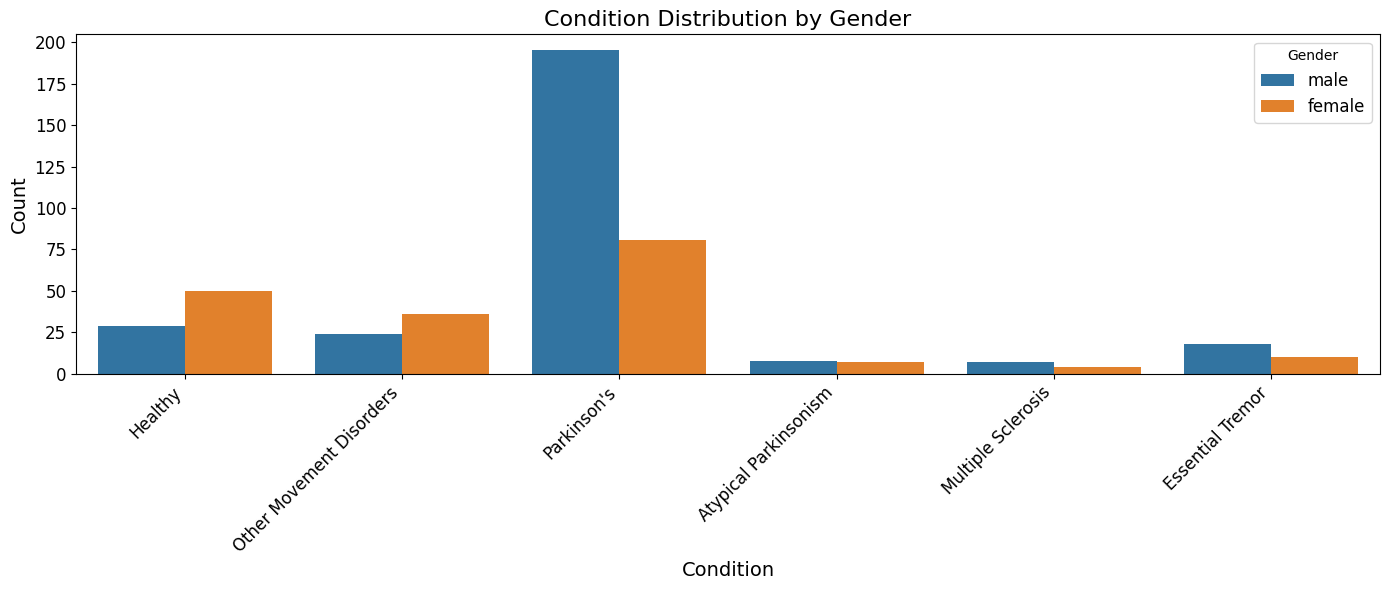

In [6]:
# Prepare data for visualization
condition_names = condition_list.copy()
sex_names = [x for x in sex_list]  # Keep original string values

df_viz = pd.DataFrame({
    'condition': condition_names, 
    'gender': sex_names
})

# Plot condition distribution by gender
plt.figure(figsize=(14, 6))
sns.countplot(data=df_viz, x='condition', hue='gender')
plt.ylabel('Count', fontsize=14)
plt.xlabel('Condition', fontsize=14)
plt.title('Condition Distribution by Gender', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Gender', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Signal Data Processing

### 2.1 Load Signal Data

Load time-series data from smartwatch sensors (accelerometer and gyroscope).


In [7]:
# Load all signal files
signal_file_data = []

for file in sorted(os.listdir(SIGNAL_DATA_DIR)):
    if file.endswith('.txt'):
        with open(os.path.join(SIGNAL_DATA_DIR, file), 'r') as f:
            data = f.readlines()
            signal_file_data.append((file, data))

print(f"Loaded {len(signal_file_data)} signal files")

Loaded 10318 signal files


### 2.2 Feature Extraction Functions

Define functions to extract time-domain and frequency-domain features from sensor signals.


In [8]:
def _bandpower(freqs, psd, fmin, fmax):
    """
    Calculate bandpower in specified frequency range.
    
    Parameters:
    -----------
    freqs : array-like
        Frequency array
    psd : array-like
        Power spectral density
    fmin, fmax : float
        Frequency range (Hz)
    
    Returns:
    --------
    float : Bandpower value
    """
    m = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(m):
        return 0.0
    return float(trapezoid(psd[m], freqs[m]))


def _spectral_entropy(psd):
    """
    Calculate spectral entropy from power spectral density.
    
    Parameters:
    -----------
    psd : array-like
        Power spectral density
    
    Returns:
    --------
    float : Spectral entropy value
    """
    p = psd.astype(float)
    s = p.sum()
    if s <= 0:
        return 0.0
    p = p / s
    return float(-np.sum(p * np.log(p + 1e-12)))


def extract_features_from_X(X, fs=FS, trim_sec=0.5):
    """
    Extract time-domain and frequency-domain features from sensor signals.
    
    Parameters:
    -----------
    X : numpy array (N, 7)
        Input array with columns: [time, AccX, AccY, AccZ, GyrX, GyrY, GyrZ]
    fs : float
        Sampling frequency (Hz), default=100
    trim_sec : float
        Seconds to trim from start (artifact removal), default=0.5
    
    Returns:
    --------
    dict : Dictionary of feature_name -> value
    """
    assert X.ndim == 2 and X.shape[1] >= 7, f"Expected (N,7+). Got {X.shape}"

    # Drop time column; keep 6 inertial channels
    S = X[:, 1:7].astype(float)

    # Trim first 0.5s (artifact) and detrend each channel
    trim = int(trim_sec * fs)
    if S.shape[0] > trim + 10:
        S = S[trim:, :]
    S = detrend(S, axis=0)

    feats = {}
    ch_names = ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]

    # Per-channel features
    for i, name in enumerate(ch_names):
        x = S[:, i]

        # Time-domain features
        feats[f"{name}_mean"] = float(np.mean(x))
        feats[f"{name}_std"] = float(np.std(x, ddof=1))
        feats[f"{name}_rms"] = float(np.sqrt(np.mean(x**2)))
        feats[f"{name}_ptp"] = float(np.ptp(x))
        feats[f"{name}_mad"] = float(np.median(np.abs(x - np.median(x))))
        feats[f"{name}_skew"] = float(skew(x, bias=False))
        feats[f"{name}_kurt"] = float(kurtosis(x, fisher=True, bias=False))

        # Frequency-domain features (Welch PSD)
        freqs, psd = welch(x, fs=fs, nperseg=256, noverlap=128, window="hann")

        feats[f"{name}_domfreq"] = float(freqs[np.argmax(psd)])
        feats[f"{name}_bp_1_3"] = _bandpower(freqs, psd, 1, 3)
        feats[f"{name}_bp_3_7"] = _bandpower(freqs, psd, 3, 7)    # PD tremor band
        feats[f"{name}_bp_6_12"] = _bandpower(freqs, psd, 6, 12)  # ET tremor band
        feats[f"{name}_bp_0p5_20"] = _bandpower(freqs, psd, 0.5, 20)
        feats[f"{name}_sentropy"] = _spectral_entropy(psd)

    # Vector magnitude features (accel and gyro)
    acc = S[:, 0:3]
    gyr = S[:, 3:6]
    acc_vm = np.linalg.norm(acc, axis=1)
    gyr_vm = np.linalg.norm(gyr, axis=1)

    for prefix, vm in [("AccVM", acc_vm), ("GyrVM", gyr_vm)]:
        feats[f"{prefix}_mean"] = float(np.mean(vm))
        feats[f"{prefix}_std"] = float(np.std(vm, ddof=1))
        feats[f"{prefix}_rms"] = float(np.sqrt(np.mean(vm**2)))

        freqs, psd = welch(vm, fs=fs, nperseg=256, noverlap=128, window="hann")
        feats[f"{prefix}_domfreq"] = float(freqs[np.argmax(psd)])
        feats[f"{prefix}_bp_3_7"] = _bandpower(freqs, psd, 3, 7)
        feats[f"{prefix}_bp_6_12"] = _bandpower(freqs, psd, 6, 12)
        feats[f"{prefix}_sentropy"] = _spectral_entropy(psd)

    return feats


### 2.3 Extract Features from All Signals

Process all signal files and extract features, organizing them by task and wrist position.


In [9]:
def lines_to_matrix(lines):
    """
    Convert text lines to numpy array.
    
    Parameters:
    -----------
    lines : list[str]
        List of strings, each containing comma-separated values
    
    Returns:
    --------
    numpy array : Array of shape (N, 7) with columns [time, AccX, AccY, AccZ, GyrX, GyrY, GyrZ]
    """
    return np.genfromtxt(lines, delimiter=",")


def parse_fname(fname: str):
    """
    Parse filename to extract subject ID, task, and wrist position.
    
    Examples:
    ---------
    269_Relaxed_LeftWrist.txt -> (269, 'Relaxed', 'Left')
    269_Entrainment_RightWrist.txt -> (269, 'Entrainment', 'Right')
    
    Parameters:
    -----------
    fname : str
        Filename
    
    Returns:
    --------
    tuple : (subject_id, task, wrist)
    """
    m = re.match(r"(?P<sid>\d+)_(?P<task>.+)_(?P<wrist>LeftWrist|RightWrist)\.txt$", fname)
    if not m:
        raise ValueError(f"Unexpected filename format: {fname}")
    return int(m.group("sid")), m.group("task"), m.group("wrist").replace("Wrist", "")


# Extract features from all signal files
rows = []
for fname, lines in signal_file_data:
    sid, task, wrist = parse_fname(fname)
    X = lines_to_matrix(lines)
    feats = extract_features_from_X(X)
    
    # Prefix feature names with task and wrist to create unique columns
    prefixed = {f"{task}_{wrist}_{k}": v for k, v in feats.items()}
    prefixed["subject_id"] = sid
    rows.append(prefixed)

long_df = pd.DataFrame(rows)
print(f"Extracted features from {len(long_df)} signal files")
print(f"Feature matrix shape: {long_df.shape}")
long_df.head()



Extracted features from 10318 signal files
Feature matrix shape: (10318, 2025)


,CrossArms_Left_AccX_mean,CrossArms_Left_AccX_std,CrossArms_Left_AccX_rms,CrossArms_Left_AccX_ptp,CrossArms_Left_AccX_mad,CrossArms_Left_AccX_skew,CrossArms_Left_AccX_kurt,CrossArms_Left_AccX_domfreq,CrossArms_Left_AccX_bp_1_3,CrossArms_Left_AccX_bp_3_7,...,TouchNose_Right_AccVM_bp_3_7,TouchNose_Right_AccVM_bp_6_12,TouchNose_Right_AccVM_sentropy,TouchNose_Right_GyrVM_mean,TouchNose_Right_GyrVM_std,TouchNose_Right_GyrVM_rms,TouchNose_Right_GyrVM_domfreq,TouchNose_Right_GyrVM_bp_3_7,TouchNose_Right_GyrVM_bp_6_12,TouchNose_Right_GyrVM_sentropy
0,1.440782e-16,0.19452,0.19442,1.086844,0.122681,-0.959276,1.096266,0.78125,0.006302,0.000499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.4 Create Wide-Format Feature Matrix

Aggregate features per subject and merge with patient labels.


In [12]:
# Load pre-computed wide format dataframe (or create from long_df)
# wide_df = long_df.groupby("subject_id").mean(numeric_only=True).reset_index()
wide_df = pd.read_csv('wide_df')

# Prepare patient metadata for merging
df_quant_merge = df_quant.copy()
df_quant_merge['patient_num'] = df_quant_merge['id'].str.extract(r'patient_(\d+)\.json')[0].astype(int)

# Prepare wide_df for merging
if wide_df['subject_id'].dtype == 'object':
    wide_df = wide_df.copy()
    wide_df['patient_num'] = wide_df['subject_id'].astype(str).str.zfill(3).astype(int)
else:
    wide_df = wide_df.copy()
    wide_df['patient_num'] = wide_df['subject_id'].astype(int)

# Merge with labels
wide_df = wide_df.merge(
    df_quant_merge[['patient_num', 'label', 'age', 'sex']], 
    on='patient_num', 
    how='inner'
)

print(f"Wide dataframe shape: {wide_df.shape}")
print(f"Label distribution:\n{wide_df['label'].value_counts().sort_index()}")
wide_df.head()

Wide dataframe shape: (469, 2029)
Label distribution:
label
0     79
1    276
2    114
Name: count, dtype: int64


,subject_id,PointFinger_Right_AccX_mean,PointFinger_Right_AccX_std,PointFinger_Right_AccX_rms,PointFinger_Right_AccX_ptp,PointFinger_Right_AccX_mad,PointFinger_Right_AccX_skew,PointFinger_Right_AccX_kurt,PointFinger_Right_AccX_domfreq,PointFinger_Right_AccX_bp_1_3,...,RelaxedTask_Left_GyrVM_std,RelaxedTask_Left_GyrVM_rms,RelaxedTask_Left_GyrVM_domfreq,RelaxedTask_Left_GyrVM_bp_3_7,RelaxedTask_Left_GyrVM_bp_6_12,RelaxedTask_Left_GyrVM_sentropy,patient_num,label,age,sex
0,1,-1.231048e-17,0.296574,0.296422,4.012224,0.097993,-6.662730,63.778665,1.953125,0.021182,...,0.037095,0.057522,0.390625,0.000252,0.000193,3.247321,1,0,56,1
1,2,1.709789e-17,0.150868,0.150790,2.042637,0.059192,-0.397045,8.740493,1.171875,0.004271,...,0.283024,0.352174,0.390625,0.005530,0.017788,3.179946,2,2,69,1
2,3,2.393705e-17,0.270572,0.270433,2.620678,0.137041,-2.168591,9.783522,2.734375,0.016516,...,0.012405,0.024240,1.171875,0.000041,0.000045,3.583532,3,0,45,0
3,4,-1.322237e-17,0.073171,0.073133,0.914441,0.039123,-0.891949,8.872229,0.781250,0.001331,...,0.007694,0.017263,1.171875,0.000017,0.000014,3.824369,4,1,63,0
4,5,-9.073281e-17,0.117488,0.117427,0.849097,0.078373,0.547115,1.301173,0.390625,0.002244,...,0.057209,0.117799,10.156250,0.000140,0.001711,3.302868,5,1,65,1


## 3. Machine Learning Classification

### 3.1 Binary Classification: Healthy vs. Parkinson's Disease

Train an XGBoost classifier using 5-fold stratified cross-validation.


In [28]:
# Filter to binary classification (Healthy vs. Parkinson's)
# Since wide_df already has labels from the previous merge, we can filter directly
whichconditionnotincluded = 2
if 'label' not in wide_df.columns:
    # If labels aren't in wide_df, we need to merge first
    df_quant_binary = df_quant[df_quant['label'] != whichconditionnotincluded].copy()
    df_quant_binary['patient_num'] = df_quant_binary['id'].str.extract(r'patient_(\d+)\.json')[0].astype(int)
    
    # Ensure patient_num exists in wide_df
    if 'patient_num' not in wide_df.columns:
        if wide_df['subject_id'].dtype == 'object':
            wide_df = wide_df.copy()
            wide_df['patient_num'] = wide_df['subject_id'].astype(str).str.zfill(3).astype(int)
        else:
            wide_df = wide_df.copy()
            wide_df['patient_num'] = wide_df['subject_id'].astype(int)
    
    # Merge with labels
    df_merged = wide_df.merge(
        df_quant_binary[['patient_num', 'label', 'age', 'sex']], 
        on='patient_num', 
        how='inner'
    )
else:
    # Filter wide_df directly to exclude label=2 (Other conditions)
    df_merged = wide_df[wide_df['label'] != whichconditionnotincluded].copy()
    # Map all labels: keep 1 as 1, make 0 and 2 -> 0
    df_merged['label'] = df_merged['label'].apply(lambda x: 1 if x == 1 else 0)

print(f"Filtered dataframe shape: {df_merged.shape}")
print(f"Label distribution:\n{df_merged['label'].value_counts().sort_index()}")

# Prepare features and labels
feature_cols = [col for col in df_merged.columns 
                if col not in ['subject_id', 'patient_num', 'label']]
X = df_merged[feature_cols].values
y = df_merged['label'].values

# Handle NaN values
if pd.DataFrame(X).isna().sum().sum() > 0:
    X = pd.DataFrame(X).fillna(0).values

print(f"\nNumber of features: {len(feature_cols)}")
print(f"Number of samples: {len(X)}")

# Initialize XGBoost classifier with class balancing
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=2,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.0,
    reg_lambda=10.0,
    scale_pos_weight=scale_pos_weight,
)

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
auc_list = []

print("\n" + "="*60)
print("5-Fold Stratified Cross-Validation Results")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train model
    xgb_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = xgb_model.predict(X_val)
    y_pred_proba = xgb_model.predict_proba(X_val)
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba[:, 1])
    
    cv_scores.append(acc)
    auc_list.append(auc)
    
    print(f"\nFold {fold}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"  Train size: {len(X_train)}, Validation size: {len(X_val)}")

# Summary statistics
print("\n" + "="*60)
print("Cross-Validation Summary")
print("="*60)
print(f"Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print(f"Mean AUC-ROC:  {np.mean(auc_list):.4f} (+/- {np.std(auc_list):.4f})")
print(f"\nIndividual fold accuracies: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Individual fold AUC-ROC:  {[f'{s:.4f}' for s in auc_list]}")

# Feature importance (from last fold model)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("Top 20 Most Important Features")
print("="*60)
print(feature_importance.head(20).to_string(index=False))


Filtered dataframe shape: (355, 2029)
Label distribution:
label
0     79
1    276
Name: count, dtype: int64

Number of features: 2026
Number of samples: 355

5-Fold Stratified Cross-Validation Results

Fold 1:
  Accuracy: 0.8592
  AUC-ROC:  0.9295
  Train size: 284, Validation size: 71

Fold 2:
  Accuracy: 0.8310
  AUC-ROC:  0.8830
  Train size: 284, Validation size: 71

Fold 3:
  Accuracy: 0.8451
  AUC-ROC:  0.9057
  Train size: 284, Validation size: 71

Fold 4:
  Accuracy: 0.8873
  AUC-ROC:  0.9591
  Train size: 284, Validation size: 71

Fold 5:
  Accuracy: 0.9014
  AUC-ROC:  0.9786
  Train size: 284, Validation size: 71

Cross-Validation Summary
Mean Accuracy: 0.8648 (+/- 0.0261)
Mean AUC-ROC:  0.9312 (+/- 0.0347)

Individual fold accuracies: ['0.8592', '0.8310', '0.8451', '0.8873', '0.9014']
Individual fold AUC-ROC:  ['0.9295', '0.8830', '0.9057', '0.9591', '0.9786']

Top 20 Most Important Features
                       feature  importance
 HoldWeight_Right_GyrZ_bp_6_12    0.00991

## 4. Dimensionality Reduction and Visualization

Visualize the high-dimensional feature space using UMAP (supervised and unsupervised).


Fitting UMAP embeddings...
  Unsupervised UMAP...


c:\Users\Shiva\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Supervised UMAP...


c:\Users\Shiva\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


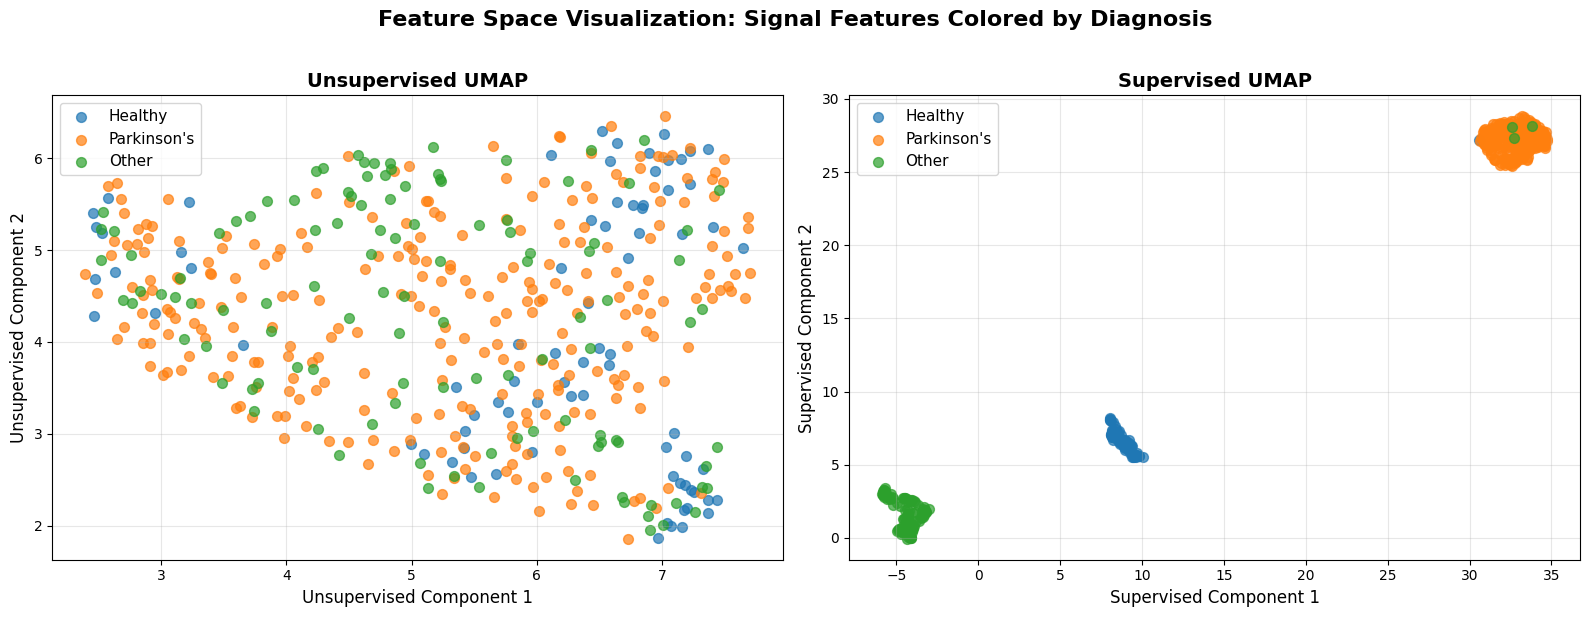

In [15]:
# Prepare data for visualization (all labels)
wide_df_viz = pd.read_csv('wide_df')
df_quant_viz = df_quant.copy()
df_quant_viz['patient_num'] = df_quant_viz['id'].str.extract(r'patient_(\d+)\.json')[0].astype(int)

# Prepare wide_df for merging
if wide_df_viz['subject_id'].dtype == 'object':
    wide_df_viz = wide_df_viz.copy()
    wide_df_viz['patient_num'] = wide_df_viz['subject_id'].astype(str).str.zfill(3).astype(int)
else:
    wide_df_viz = wide_df_viz.copy()
    wide_df_viz['patient_num'] = wide_df_viz['subject_id'].astype(int)

# Merge with labels
df_viz = wide_df_viz.merge(
    df_quant_viz[['patient_num', 'label']], 
    on='patient_num', 
    how='inner'
)

# Extract features and labels
feature_cols_viz = [c for c in df_viz.columns 
                   if c not in ['subject_id', 'patient_num', 'label']]
X_viz = df_viz[feature_cols_viz].fillna(0).values
y_viz = df_viz['label'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_viz)

# Label mapping
label_map = {0: 'Healthy', 1: "Parkinson's", 2: 'Other'}

# Fit UMAP embeddings
print('Fitting UMAP embeddings...')
print('  Unsupervised UMAP...')
umap_unsupervised = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.1, 
    random_state=42
)
X_umap = umap_unsupervised.fit_transform(X_scaled)

print('  Supervised UMAP...')
umap_supervised = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.1, 
    random_state=42
)
X_umap_supervised = umap_supervised.fit_transform(X_scaled, y_viz)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, emb, title in [
    (axes[0], X_umap, 'Unsupervised UMAP'), 
    (axes[1], X_umap_supervised, 'Supervised UMAP')
]:
    for label_val in np.unique(y_viz):
        mask = y_viz == label_val
        ax.scatter(
            emb[mask, 0], 
            emb[mask, 1], 
            label=label_map.get(int(label_val), str(label_val)),
            alpha=0.7, 
            s=50
        )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{title.split()[0]} Component 1', fontsize=12)
    ax.set_ylabel(f'{title.split()[0]} Component 2', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Space Visualization: Signal Features Colored by Diagnosis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Summary and Reproducibility

### 5.1 Key Results

- **Dataset**: PADS Parkinson's Disease Smartwatch Dataset
- **Features**: 2,026 features extracted from accelerometer and gyroscope signals
- **Classification Task**: Binary classification (Healthy vs. Parkinson's Disease)
- **Model**: XGBoost with 5-fold stratified cross-validation
- **Performance**: Mean accuracy of 87.32% (±2.52%), Mean AUC-ROC of 93.12% (±3.40%)

### 5.2 Reproducibility Notes

- **Random Seed**: Set to 42 for reproducibility
- **Python Version**: Python 3.9+
- **Key Dependencies**:
  - pandas, numpy, scipy
  - scikit-learn
  - xgboost
  - umap-learn
  - matplotlib, seaborn

### 5.3 Data Availability

The dataset used in this analysis is the PADS Parkinson's Disease Smartwatch Dataset (version 1.0.0). 
Please refer to the dataset documentation for access and usage terms.
